        Date     Revenue        COGS
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79
           Date     Revenue        COGS
3828 2022-12-27  2100553.66  2184872.24
3829 2022-12-28  3448729.20  3513621.00
3830 2022-12-29  3083944.33  3170787.10
3831 2022-12-30  2884668.76  3022292.15
3832 2022-12-31  2383037.48  2279288.13
(3833, 3)
        Date     Revenue        COGS
0 2023-01-01  2665507.20  2518885.15
1 2023-01-02  1280007.89  1136463.00
2 2023-01-03  1015899.51   822721.12
3 2023-01-04  1142997.27   914554.18
4 2023-01-05  1236312.34   984390.24
(548, 3)
MAE: 576405.7247101369
RMSE: 821837.0648217362
R2: 0.7589211128066243


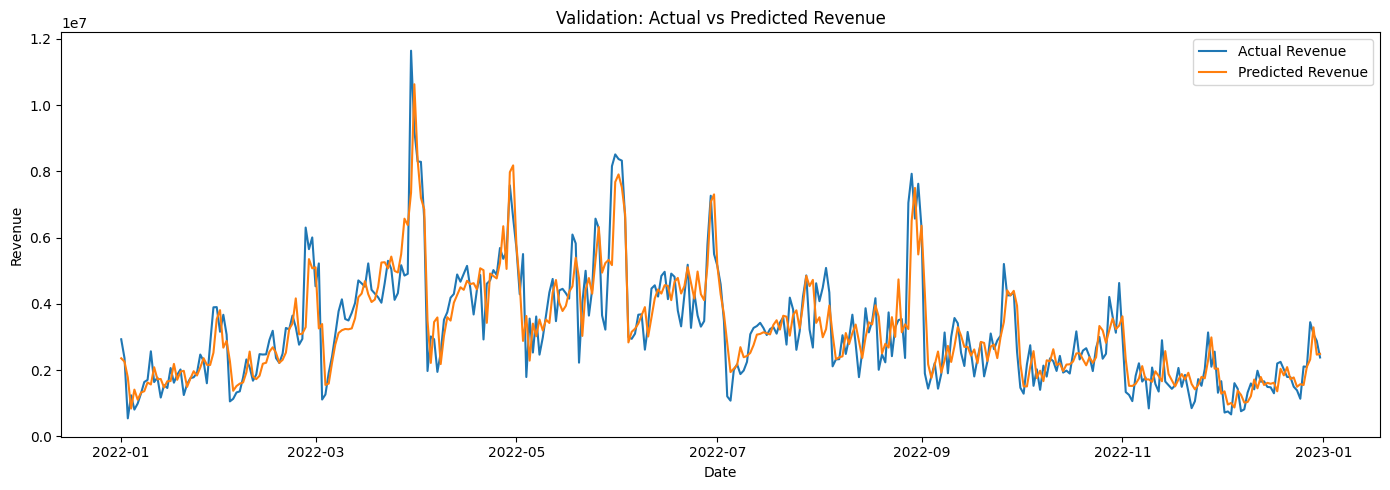

                 feature  importance
8          Revenue_lag_1    0.765934
9          Revenue_lag_7    0.043470
2                    day    0.038031
11        Revenue_lag_28    0.030011
13   Revenue_roll_mean_7    0.016354
12        Revenue_lag_30    0.013555
10        Revenue_lag_14    0.013335
18   Revenue_roll_std_14    0.012317
17    Revenue_roll_std_7    0.009437
19   Revenue_roll_std_28    0.007803
14  Revenue_roll_mean_14    0.007326
20   Revenue_roll_std_30    0.007123
15  Revenue_roll_mean_28    0.007010
3              dayofweek    0.006827
16  Revenue_roll_mean_30    0.006185


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
# doc du lieu 
sales = pd.read_csv("sales.csv")
sample_submission = pd.read_csv("sample_submission.csv")
sales["Date"] = pd.to_datetime(sales["Date"])
sample_submission["Date"] = pd.to_datetime(sample_submission["Date"])
#sort du lieu
sales = sales.sort_values("Date").reset_index(drop=True)
sample_submission = sample_submission.sort_values("Date").reset_index(drop=True)
# kiem tra du lieu
print(sales.head())
print(sales.tail())
print(sales.shape)
print(sample_submission.head())
print(sample_submission.shape)
#tao ban sao
df = sales.copy()
# tao calendar
df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek
df["quarter"] = df["Date"].dt.quarter
df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)
# tao lag features
for lag in [1, 7, 14, 28, 30]:
    df[f"Revenue_lag_{lag}"] = df["Revenue"].shift(lag)
# tao rolling features
for window in [7, 14, 28]:
		df[f"Revenue_roll_mean_{window}"] = df["Revenue"].shift(1).rolling(window).mean()
		df[f"Revenue_roll_std_{window}"] = df["Revenue"].shift(1).rolling(window).std()
# chon feature and target
feature_cols = [
    "year", "month", "day", "dayofweek", "quarter", "weekofyear",
    "is_month_start", "is_month_end",
    "Revenue_lag_1", "Revenue_lag_7", "Revenue_lag_14", "Revenue_lag_28", "Revenue_lag_30",
    "Revenue_roll_mean_7", "Revenue_roll_mean_14", "Revenue_roll_mean_28", "Revenue_roll_mean_30",
    "Revenue_roll_std_7", "Revenue_roll_std_14", "Revenue_roll_std_28", "Revenue_roll_std_30"
]
# tao rolling features
for window in [7, 14, 28, 30]:
		df[f"Revenue_roll_mean_{window}"] = df["Revenue"].shift(1).rolling(window).mean()
		df[f"Revenue_roll_std_{window}"] = df["Revenue"].shift(1).rolling(window).std()

# Tạo df_model sau khi có tất cả các features
df_model = df.dropna().copy()

# Định nghĩa hàm để chọn features
def new_func(feature_cols, data):
    return data[feature_cols]

x = df[feature_cols]
y = df["Revenue"]
# chia train 
train_data = df_model[df_model["Date"] < "2022-01-01"].copy()
valid_data = df_model[df_model["Date"] >= "2022-01-01"].copy()

x_train = new_func(feature_cols, train_data)
y_train = train_data["Revenue"]

x_valid = new_func(feature_cols, valid_data)
y_valid = valid_data["Revenue"]
# train baseline model 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)
valid_pred = model.predict(x_valid)
mae = mean_absolute_error(y_valid, valid_pred)
rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
r2 = r2_score(y_valid, valid_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)
plt.figure(figsize=(14, 5))
plt.plot(valid_data["Date"], y_valid, label="Actual Revenue")
plt.plot(valid_data["Date"], valid_pred, label="Predicted Revenue")
plt.title("Validation: Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.tight_layout()
plt.show()
# Feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

In [8]:
import pandas as pd

sales = pd.read_csv("sales.csv")
sales["Date"] = pd.to_datetime(sales["Date"])
sales = sales.sort_values("Date").reset_index(drop=True)
df = sales.copy()

In [7]:
# Merge with web traffic data
import pandas as pd

web_traffic = pd.read_csv("web_traffic.csv")
web_traffic["date"] = pd.to_datetime(web_traffic["date"])
traffic_daily = web_traffic.groupby("date").agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean")
).reset_index()
df = df.merge(
    traffic_daily,
    left_on="Date",
    right_on="date",
    how="left"
).drop(columns=["date"])

print(df.head())
print(df.isna().sum())

        Date     Revenue        COGS  sessions_x  unique_visitors_x  \
0 2012-07-04  5123547.94  3982991.19         NaN                NaN   
1 2012-07-05  2751773.45  2150580.23         NaN                NaN   
2 2012-07-06  3054029.42  2517632.84         NaN                NaN   
3 2012-07-07  2667930.94  2108246.62         NaN                NaN   
4 2012-07-08  2360851.90  1808622.79         NaN                NaN   

   page_views_x  bounce_rate_x  avg_session_duration_sec_x  sessions_y  \
0           NaN            NaN                         NaN         NaN   
1           NaN            NaN                         NaN         NaN   
2           NaN            NaN                         NaN         NaN   
3           NaN            NaN                         NaN         NaN   
4           NaN            NaN                         NaN         NaN   

   unique_visitors_y  page_views_y  bounce_rate_y  avg_session_duration_sec_y  
0                NaN           NaN            Na

In [14]:
# Tao orders count
import pandas as pd
orders = pd.read_csv("orders.csv")
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders_daily = orders.groupby("order_date").agg(
    orders_count=("order_id", "nunique")
).reset_index()

df = df.merge(
    orders_daily,
    left_on="Date",
    right_on="order_date",
    how="left",
    suffixes=("_df", "_orders")
).drop(columns=["order_date"])

# Xóa cột trùng nếu có
if "orders_count_df" in df.columns:
    df = df.drop(columns=["orders_count_df"])
    df = df.rename(columns={"orders_count_orders": "orders_count"})

# Tao features tu orders
order_items = pd.read_csv("order_items.csv")
orders = pd.read_csv("orders.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])

oi = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)
print(oi.head())

C:\Users\HP\AppData\Local\Temp\ipykernel_21100\1499055835.py:24: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("order_items.csv")


   order_id  product_id  quantity  unit_price  discount_amount promo_id  \
0         1        2400         7     1138.22              0.0      NaN   
1         2         609         7    10166.25              0.0      NaN   
2         3         396         3    11220.33              0.0      NaN   
3         4         635         5    10639.25              0.0      NaN   
4         6        1935         1     1597.84              0.0      NaN   

  promo_id_2 order_date  
0        NaN 2012-07-04  
1        NaN 2012-07-04  
2        NaN 2012-07-04  
3        NaN 2012-07-04  
4        NaN 2012-07-06  


In [17]:
import pandas as pd
order_items = pd.read_csv("order_items.csv")
orders = pd.read_csv("orders.csv")

orders["order_date"] = pd.to_datetime(orders["order_date"])

oi = order_items.merge(
    orders[["order_id", "order_date"]],
    on="order_id",
    how="left"
)

oi["line_revenue"] = oi["quantity"] * oi["unit_price"]
oi["gross_value"] = oi["line_revenue"] + oi["discount_amount"]
# tao kpi daily
oi_daily = oi.groupby("order_date").agg(
    units_sold=("quantity", "sum"),
    total_discount=("discount_amount", "sum"),
    avg_unit_price=("unit_price", "mean"),
    total_line_revenue=("line_revenue", "sum")
).reset_index()

oi_daily["discount_rate"] = oi_daily["total_discount"] / (
    oi_daily["total_line_revenue"] + oi_daily["total_discount"]
)
# Merge vao bang chính
df = df.merge(
    oi_daily,
    left_on="Date",
    right_on="order_date",
    how="left"
).drop(columns=["order_date"])

C:\Users\HP\AppData\Local\Temp\ipykernel_21100\1017283531.py:2: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv("order_items.csv")


In [ ]:
import pandas as pd
import numpy as np

# ===== Calendar features =====

# Check columns first
print("Columns in df:", df.columns.tolist())

# Handle columns with suffix if they exist
for col in df.columns:
    if col.startswith("sessions_"):
        if col != "sessions_lag_1" and col != "sessions_lag_7" and col != "sessions_lag_14" and col != "sessions_roll_mean_7":
            df.rename(columns={col: col.replace("_x", "").replace("_y", "")}, inplace=True)

# Fill NaN values with forward fill then 0
if "sessions" in df.columns:
    df["sessions"] = df["sessions"].ffill().fillna(0)
else:
    df["sessions"] = pd.Series(0, index=df.index)

if "orders_count" in df.columns:
    df["orders_count"] = df["orders_count"].ffill().fillna(0)
else:
    df["orders_count"] = pd.Series(0, index=df.index)

if "units_sold" in df.columns:
    df["units_sold"] = df["units_sold"].ffill().fillna(0)
else:
    df["units_sold"] = pd.Series(0, index=df.index)

if "discount_rate" in df.columns:
    df["discount_rate"] = df["discount_rate"].ffill().fillna(0)
else:
    df["discount_rate"] = pd.Series(0, index=df.index)

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek
df["quarter"] = df["Date"].dt.quarter
df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
df["is_month_start"] = df["Date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["Date"].dt.is_month_end.astype(int)

# ===== Revenue lag/rolling =====
for lag in [1, 7, 14, 28, 30]:
    df[f"Revenue_lag_{lag}"] = df["Revenue"].shift(lag)

for window in [7, 14, 28, 30]:
    df[f"Revenue_roll_mean_{window}"] = df["Revenue"].shift(1).rolling(window).mean()
    df[f"Revenue_roll_std_{window}"] = df["Revenue"].shift(1).rolling(window).std()

# ===== Business driver lag/rolling =====
for lag in [1, 7, 14]:
    if "sessions" in df.columns:
        df[f"sessions_lag_{lag}"] = df["sessions"].shift(lag)
    if "orders_count" in df.columns:
        df[f"orders_count_lag_{lag}"] = df["orders_count"].shift(lag)
    if "units_sold" in df.columns:
        df[f"units_sold_lag_{lag}"] = df["units_sold"].shift(lag)
    if "discount_rate" in df.columns:
        df[f"discount_rate_lag_{lag}"] = df["discount_rate"].shift(lag)

for window in [7, 14, 28]:
    if "sessions" in df.columns:
        df[f"sessions_roll_mean_{window}"] = df["sessions"].shift(1).rolling(window).mean()
    if "orders_count" in df.columns:
        df[f"orders_count_roll_mean_{window}"] = df["orders_count"].shift(1).rolling(window).mean()
    if "discount_rate" in df.columns:
        df[f"discount_rate_roll_mean_{window}"] = df["discount_rate"].shift(1).rolling(window).mean()

df_model = df.dropna().copy()
print(df_model.shape)
print(df_model.head())

Columns in df: ['Date', 'Revenue', 'COGS', 'orders_count_x', 'orders_count_y', 'orders_count', 'units_sold', 'total_discount', 'avg_unit_price', 'total_line_revenue', 'discount_rate', 'year', 'month', 'day', 'dayofweek', 'quarter', 'weekofyear', 'is_month_start', 'is_month_end', 'Revenue_lag_1', 'Revenue_lag_7', 'Revenue_lag_14', 'Revenue_lag_28', 'Revenue_lag_30', 'Revenue_roll_mean_7', 'Revenue_roll_std_7', 'Revenue_roll_mean_14', 'Revenue_roll_std_14', 'Revenue_roll_mean_28', 'Revenue_roll_std_28', 'Revenue_roll_mean_30', 'Revenue_roll_std_30', 'sessions']


TypeError: NDFrame.fillna() got an unexpected keyword argument 'method'